In [35]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt


paths = glob.glob("/data/user/fkrafft/csky_king_tests/binning_scan/*/summary.json")

rows = []
for path in paths:
    with open(path) as f:
        d = json.load(f)

    rows.append({
        "id": d["id"],
        "status": d["status"],
        "runtime_sec": d["runtime_sec"],
        "minimum_counts": d["minimum_counts"],
        "sigma_bins": d["parametrization_bins"]["sigma"],
        "score": d["score"],
        "median_rms": d["median_rms"],
        "p90_rms": d["p90_rms"],
        "frac_skipped": d["frac_skipped"],
        "frac_failed": d["frac_failed"],
        "fit_npz": d["fit_npz"],
    })

df = pd.DataFrame(rows)
df = df[df["status"] == "done"].copy()
df = df.sort_values(["score"])

df.head()


,id,status,runtime_sec,minimum_counts,sigma_bins,score,median_rms,p90_rms,frac_skipped,frac_failed,fit_npz
21,E6_D9_S10_MC500,done,671.860527,500,10,0.040172,0.008823,0.028706,0.302222,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...
2,E6_D9_S10_MC750,done,636.863984,750,10,0.040312,0.008324,0.027353,0.351111,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...
1,E6_D9_S10_MC1000,done,658.392817,1000,10,0.041261,0.008052,0.027315,0.382222,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...
12,E6_D9_S05_MC200,done,618.777599,100,5,0.041520,0.009609,0.047428,0.164444,0.002963,/data/user/fkrafft/csky_king_tests/binning_sca...
10,E6_D9_S08_MC200,done,711.565507,100,8,0.042340,0.010536,0.041265,0.188889,0.000926,/data/user/fkrafft/csky_king_tests/binning_sca...


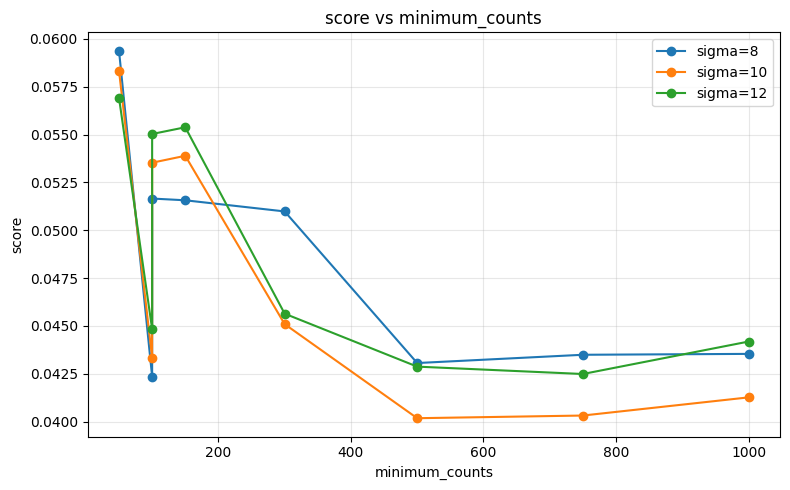

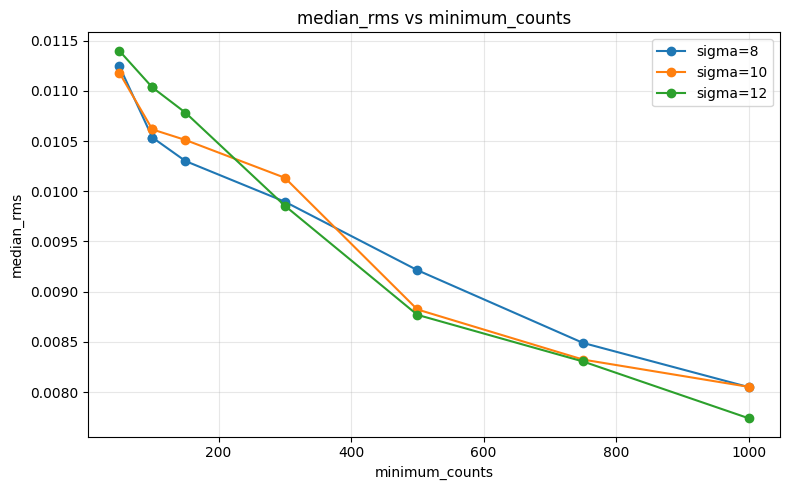

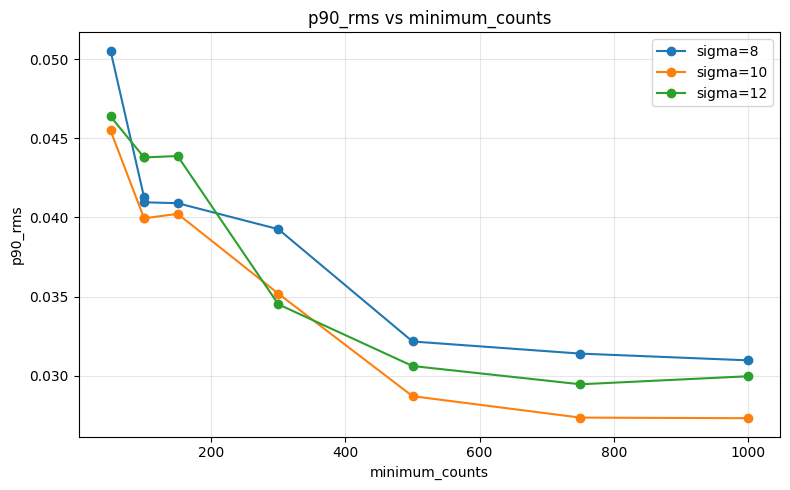

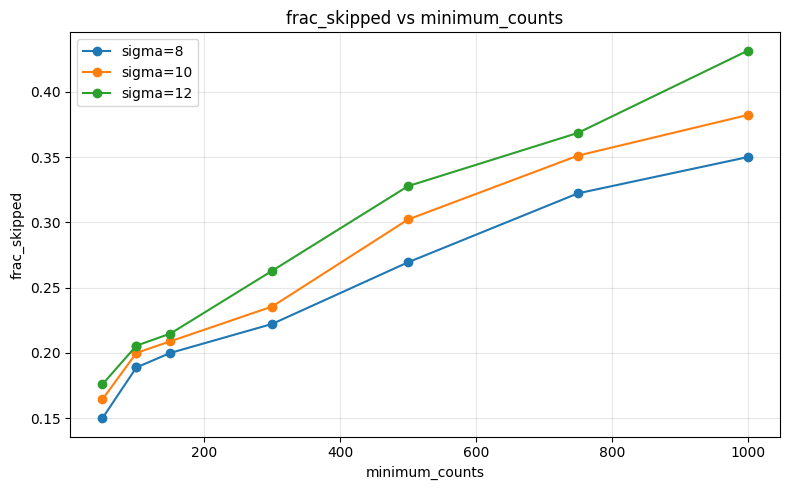

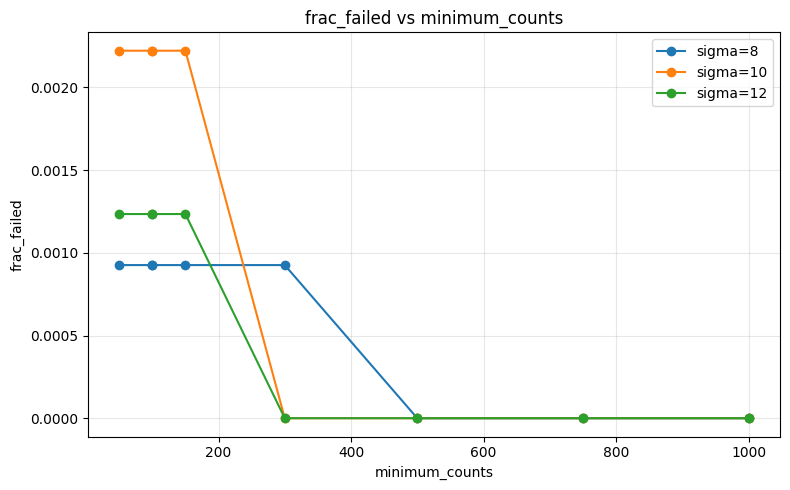

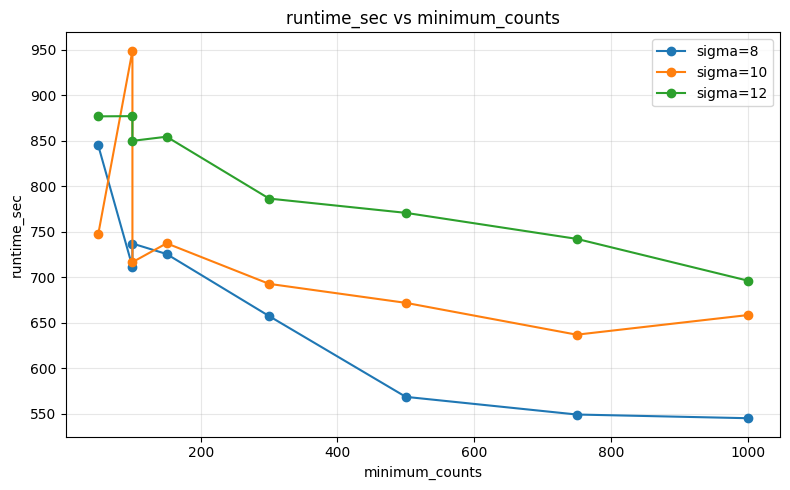

In [36]:
metrics = [
    "score",
    "median_rms",
    "p90_rms",
    "frac_skipped",
    "frac_failed",
    "runtime_sec",
]

sigmas_to_plot = [8, 10, 12]

for metric in metrics:

    plt.figure(figsize=(8, 5))

    for sigma in sigmas_to_plot:

        sub = (
            df[df["sigma_bins"] == sigma]
            .sort_values("minimum_counts")
        )

        plt.plot(
            sub["minimum_counts"],
            sub[metric],
            marker="o",
            label=f"sigma={sigma}",
        )

    plt.xlabel("minimum_counts")
    plt.ylabel(metric)
    plt.title(f"{metric} vs minimum_counts")

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [37]:
# recompute custom score

median_weight = 0.3
alpha_weight = 1.0
beta_weight = 0.1
mu_weight = 2.0

df["custom_score"] = (
    median_weight * df["median_rms"]
    + alpha_weight * df["p90_rms"]
    + beta_weight * df["frac_skipped"]
    + mu_weight * df["frac_failed"]
)

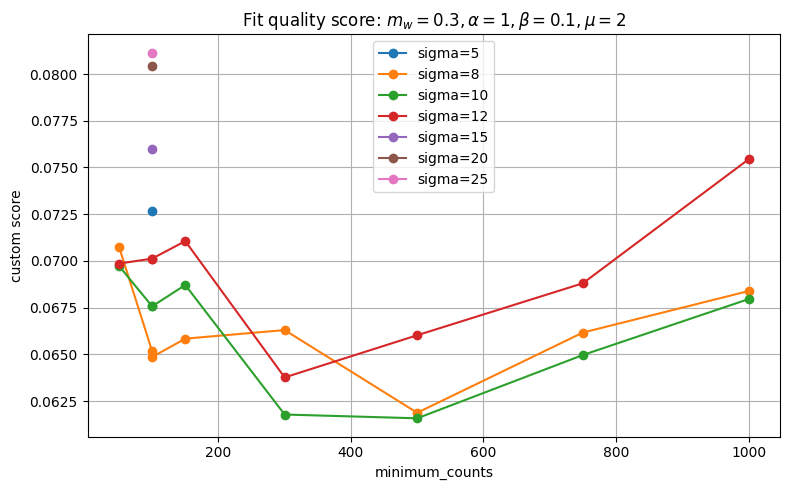

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for sigma in sorted(df["sigma_bins"].unique()):

    sub = (
        df[df["sigma_bins"] == sigma]
        .sort_values("minimum_counts")
    )

    plt.plot(
        sub["minimum_counts"],
        sub["custom_score"],
        marker="o",
        label=f"sigma={sigma}",
    )

plt.xlabel("minimum_counts")
plt.ylabel("custom score")
plt.title(r"Fit quality score: $m_w = 0.3, \alpha = 1, \beta = 0.1, \mu = 2$")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()